--- Starting MLP (Multi-Layer Perceptron) Consumption Forecasting ---
--- Reproducibility Seed Set: 42 ---
Training MLP with 100 neurons in hidden layers...
Config: 100 neurons | MAPE: 0.11%
Training MLP with 200 neurons in hidden layers...
Config: 200 neurons | MAPE: 0.08%
Training MLP with 300 neurons in hidden layers...
Config: 300 neurons | MAPE: 0.05%

BEST NETWORK CONFIGURATION:
Hidden Layer Neurons: 300
Minimum MAPE: 0.05%

Comparison Results (Final Window):
            Real Value  Predicted Value
Date                                   
2024-07-01      161149    183059.359375
2024-08-01      169700    164836.640625
2024-09-01      180721    163772.250000
2024-10-01      173691    172921.015625
2024-11-01      179036    172664.218750
2024-12-01      182626    179689.062500

Success! Validation chart saved at: E:\Projetos\ABMS-WP\figuras\figure-mlp-forecast-validation.pdf


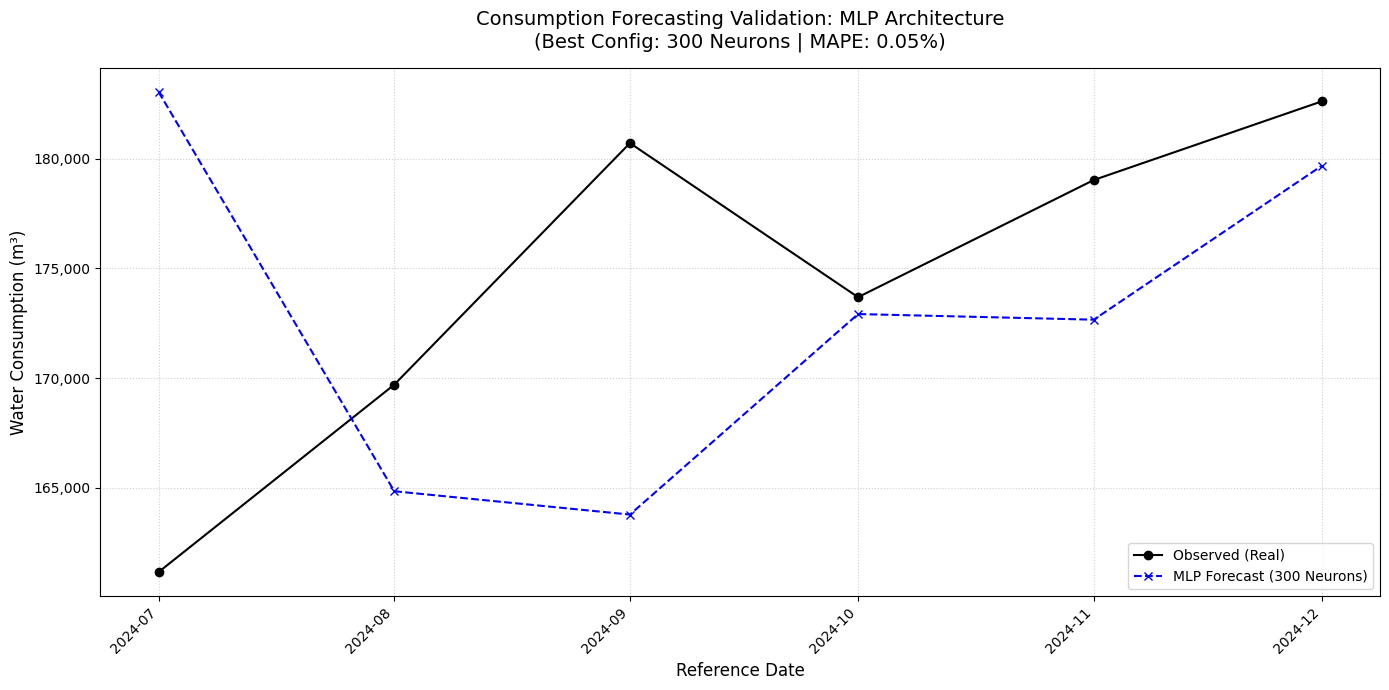

In [ ]:
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_percentage_error as mape
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# ==========================================
# 1. Configuration and Reproducibility
# ==========================================
BASE_PATH = 'E:\\Projetos\\ABM-WP'
INPUT_FILE = os.path.join(BASE_PATH, 'includes', 'Tabela_consumo_Itapua_120m.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-mlp-forecast-validation.pdf'

def set_reproducibility(seed=42):
    """
    Ensures reproducible results across Python, NumPy, and TensorFlow.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"--- Reproducibility Seed Set: {seed} ---")

def mape_loss(y_true, y_pred):
    """
    Custom Mean Absolute Percentage Error (MAPE) loss function for Keras.
    """
    y_true = tf.cast(y_true, dtype=tf.float32)
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100

def create_dataset(data, look_back=1):
    """
    Converts time series data into a supervised learning format.
    """
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        Y.append(data[i + look_back])
    return np.array(X), np.array(Y)

def main():
    print("--- Starting MLP (Multi-Layer Perceptron) Consumption Forecasting ---")
    set_reproducibility(42)

    # ==========================================
    # 2. Data Loading and Preprocessing
    # ==========================================
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file not found at {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    
    # Aggregation and Sorting
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    ts = df_aggregated.set_index('AM_REFERENCIA')['HCLQTCON']

    # Train-Test Split (Chronological)
    train = ts['2015-01':'2023-12']
    test = ts['2024-01':'2024-12']

    look_back = 6
    X_train, Y_train = create_dataset(train.values, look_back)
    X_test, Y_test = create_dataset(test.values, look_back)

    if len(X_train) == 0 or len(X_test) == 0:
        print("Error: Insufficient data. Please reduce look_back.")
        return

    # ==========================================
    # 3. Model Training and Hyperparameter Tuning
    # ==========================================
    neurons_list = [100, 200, 300]
    best_mape = float('inf')
    best_config = None
    best_predictions = None

    for neurons in neurons_list:
        print(f"Training MLP with {neurons} neurons in hidden layers...")
        
        # Build MLP Architecture
        model = Sequential([
            Dense(neurons, input_dim=look_back, activation='relu'),
            Dense(neurons // 2, activation='relu'),
            Dense(neurons // 2, activation='relu'),
            Dense(25, activation='relu'),
            Dense(1) # Output layer
        ])

        optimizer = Adam(learning_rate=0.01)
        model.compile(loss=mape_loss, optimizer=optimizer)
        
        # Train model (Silent mode: verbose=0)
        model.fit(X_train, Y_train, epochs=100, batch_size=1, verbose=0)

        # Evaluate
        predictions = model.predict(X_test, verbose=0).flatten()
        mape_val = mape(Y_test, predictions)
        print(f"Config: {neurons} neurons | MAPE: {mape_val:.2f}%")

        if mape_val < best_mape:
            best_mape = mape_val
            best_config = neurons
            best_predictions = predictions

    # ==========================================
    # 4. Results and Best Configuration
    # ==========================================
    print("\n" + "="*30)
    print(f"BEST NETWORK CONFIGURATION:")
    print(f"Hidden Layer Neurons: {best_config}")
    print(f"Minimum MAPE: {best_mape:.2f}%")
    print("="*30)

    # Comparison DataFrame
    test_dates = test.index[look_back:]
    comparison_df = pd.DataFrame({
        'Date': test_dates,
        'Real Value': Y_test,
        'Predicted Value': best_predictions
    }).set_index('Date')

    print("\nComparison Results (Final Window):")
    print(comparison_df)

    # ==========================================
    # 5. Visualization and Export
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(comparison_df.index, comparison_df['Real Value'], 
            label='Observed (Real)', color='black', marker='o', linestyle='-')
    ax.plot(comparison_df.index, comparison_df['Predicted Value'], 
            label=f'MLP Forecast ({best_config} Neurons)', color='blue', marker='x', linestyle='--')

    ax.set_title(f"Consumption Forecasting Validation: MLP Architecture\n(Best Config: {best_config} Neurons | MAPE: {best_mape:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    # Format Y axis with thousands separator
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()

    # Save to PDF
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"\nSuccess! Validation chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()